In [1]:
import torch
print(torch.__version__)
#import torchvision
#import torch.nn as nn

import os
#matplotlib.use('Agg')
%matplotlib inline

from data_loader import get_train_val_loader, get_test_loader
from autoencoder_helpers import *
from modules import *
from model_testing import *
from sklearn.decomposition import PCA
from PIL import Image
import re

#GPU/CUDA setup
if torch.cuda.is_available():
    print("CUDA enabled!")
    device = torch.device('cuda:0')  # You can specify the index of the CUDA device you want to use
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Specify the index of the GPU(s) you want to use
else:
    print("CUDA not available. Using CPU.")
    device = torch.device('cpu')

input_height = 28         # MNIST data input shape
input_width = input_height
  
data_folder = 'data'
batch_size = 250
n_workers = 0
random_seed = 0

# download MNIST data
test_loader = get_test_loader(data_folder, batch_size, shuffle=True, num_workers=n_workers, pin_memory=True)

# download MNIST data
train_loader, val_loader = get_train_val_loader(data_folder, batch_size, random_seed, augment=False, val_size=0.2,
                           shuffle=True, show_sample=False, num_workers=0, pin_memory=True)

2.2.0+cpu
CUDA not available. Using CPU.


In [2]:
#Paths to saved models
paths = {"B30": "saved_model\mnist_model\mnist_cae_balanced_clstsep_1500_0.002_250_True_0.0_20_1_1_1_1.0_0.0_30_4_32_1",
         "S30": "saved_model\mnist_model\mnist_cae_standard_default_1500_0.002_250_False_0.5_20_1_1_1_0.8_0.2_30_4_32_1",
         "S15": "saved_model\mnist_model\mnist_cae_standard_default_1500_0.002_250_False_0.5_20_1_1_1_0.8_0.2_15_4_32_1",
         "RS30": "saved_model\mnist_model\mnist_cae_adversarial_standard_default_pdglinf_ce_20_0.3_0.02_True_1500_0.002_250_False_0.5_20_1_1_1_0.8_0.2_1.0_30_4_32_1",
         "RB30": "saved_model\mnist_model\mnist_cae_adversarial_balanced_clstsep_pdglinf_ce_20_0.3_0.02_True_800_0.002_250_True_0.0_20_1_1_1_1.0_0.0_1.0_30_4_32_1",
         "FTB30n": "saved_model\mnist_model\mnist_cae_FT_30_nothing_pdglinf_ce_20_0.3_0.02_True_20_0.002_250_20_1_1_1_1.0_0.0_1",
         "FTB30a": "saved_model\mnist_model\mnist_cae_FT_30_autoencoder_pdglinf_ce_20_0.3_0.02_True_20_0.002_250_20_1_1_1_1.0_0.0_1",
         "FTB30p": "saved_model\mnist_model\mnist_cae_FT_30_prototypes_pdglinf_ce_20_0.3_0.02_True_20_0.002_250_20_1_1_1_1.0_0.0_1"}

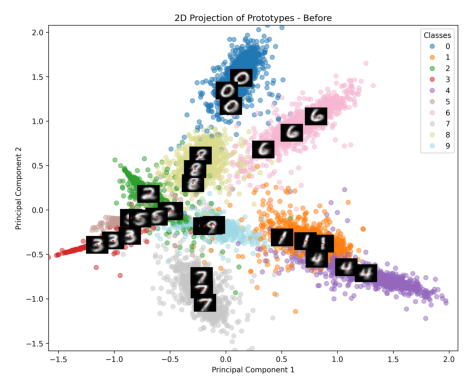

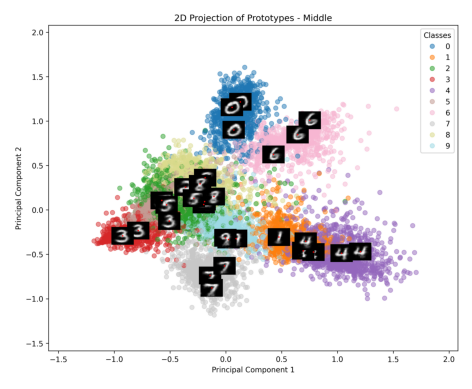

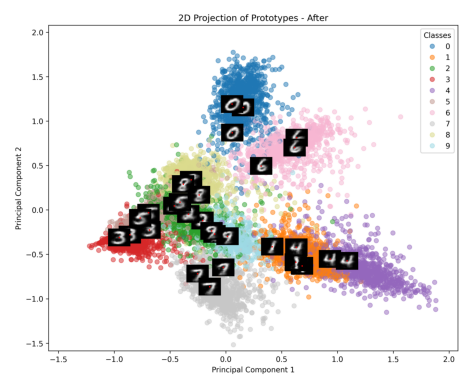

In [13]:
# Path to the directory containing model files
directory_path = paths["FTB30n"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# List of specific model files to process
specific_models = ["mnist_cae_adv00000.pth", "mnist_cae_adv00010.pth", "mnist_cae_adv00020.pth"]

# Plot and save the images for the specific models
for idx, model_file in enumerate(specific_models):
    model_path = os.path.join(directory_path, model_file)
    
    # Load the model and fit PCA to the test data
    model = torch.load(model_path, map_location="cpu", weights_only=False)
    model.to(device)
    model.eval()
    reduced_test_data, test_labels, pca = get_encoded_test_data_and_fit_pca(test_loader, model, device)
    
    # Project prototypes using the same loaded model (avoid re-loading inside helper)
    prototype_distances = model.prototype_layer.prototype_distances.to(device)
    prototype_imgs = model.decoder(prototype_distances.reshape((-1, 10, 2, 2))).detach().cpu()
    reduced_prototypes = pca.transform(
        prototype_distances.detach().cpu().numpy().reshape(prototype_distances.size(0), -1)
    )
    
    # Calculate the x and y limits for the current model's data
    xlim = (min(reduced_test_data[:, 0].min(), reduced_prototypes[:, 0].min()), max(reduced_test_data[:, 0].max(), reduced_prototypes[:, 0].max()))
    ylim = (min(reduced_test_data[:, 1].min(), reduced_prototypes[:, 1].min()), max(reduced_test_data[:, 1].max(), reduced_prototypes[:, 1].max()))
    
    if idx == 0:
        title = '2D Projection of Prototypes - Before'
    elif idx == len(specific_models) - 1:
        title = '2D Projection of Prototypes - After'
    else:
        title = '2D Projection of Prototypes - Middle'
    
    save_path = os.path.join(directory_path, f'{model_file}_projection.png')
    plot_prototype_projection_with_data(reduced_prototypes, prototype_imgs, reduced_test_data, test_labels, title, xlim, ylim, save_path)
    
    image = plt.imread(save_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

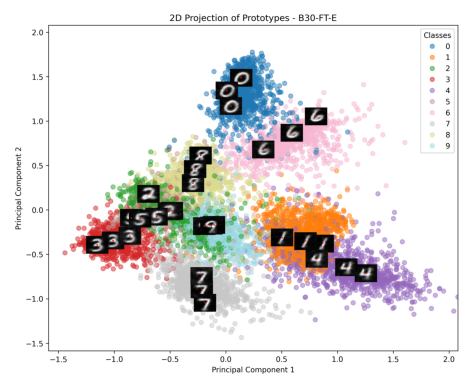

In [16]:
# B30-FT-E latent space projection (same workflow style as above)
base_model_path = os.path.join(paths["B30"], "mnist_cae00750.pth")
b30_ft_e_checkpoint = os.path.join(
    "tfg_models", "B30", "B30-FT-E", "seed=1", "checkpoints",
    "B30_B30-FT-E_seed1_best_val_adv_acc.pth"
)

# Keep the same structure as the previous cell: load model, fit PCA, project prototypes, plot and show
model = torch.load(base_model_path, map_location=device, weights_only=False)
state = torch.load(b30_ft_e_checkpoint, map_location=device)
model.load_state_dict(state["model_state"] if "model_state" in state else state)
model.to(device)
model.eval()

reduced_test_data, test_labels, pca = get_encoded_test_data_and_fit_pca(test_loader, model, device)

# Same projection logic as get_prototype_projection, but using the already-loaded FT model
prototype_distances = model.prototype_layer.prototype_distances.to(device)
prototype_imgs = model.decoder(prototype_distances.reshape((-1, 10, 2, 2))).detach().cpu()
reduced_prototypes = pca.transform(
    prototype_distances.detach().cpu().numpy().reshape(prototype_distances.size(0), -1)
)

xlim = (
    min(reduced_test_data[:, 0].min(), reduced_prototypes[:, 0].min()),
    max(reduced_test_data[:, 0].max(), reduced_prototypes[:, 0].max()),
)
ylim = (
    min(reduced_test_data[:, 1].min(), reduced_prototypes[:, 1].min()),
    max(reduced_test_data[:, 1].max(), reduced_prototypes[:, 1].max()),
)

title = "2D Projection of Prototypes - B30-FT-E"
save_path = os.path.join(
    "tfg_models", "B30", "B30-FT-E", "seed=1", "B30-FT-E_projection.png"
)

plot_prototype_projection_with_data(
    reduced_prototypes, prototype_imgs, reduced_test_data, test_labels, title, xlim, ylim, save_path
)

image = plt.imread(save_path)
plt.imshow(image)
plt.axis("off")
plt.show()

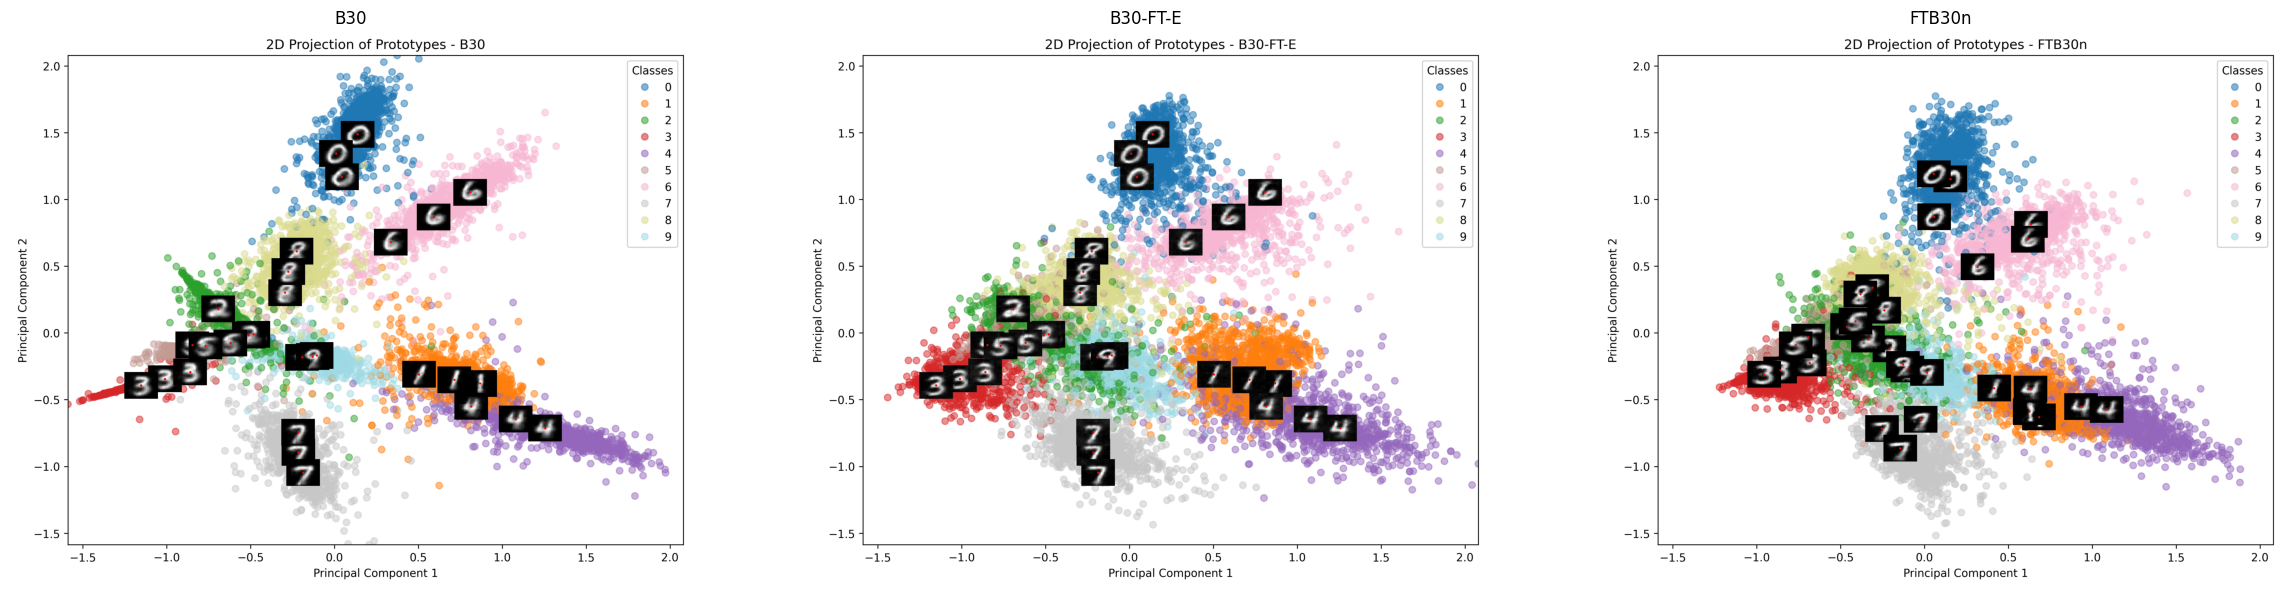

In [15]:
# Compare latent space projection: B30 vs B30-FT-E vs FTB30n
import numpy as np

base_model_path = os.path.join(paths["B30"], "mnist_cae00750.pth")
b30_ft_e_checkpoint = os.path.join(
    "tfg_models", "B30", "B30-FT-E", "seed=1", "checkpoints",
    "B30_B30-FT-E_seed1_best_val_adv_acc.pth"
)
ftb30n_model_path = os.path.join(paths["FTB30n"], "mnist_cae_adv00020.pth")
save_dir = os.path.join("tfg_models", "B30", "B30-FT-E", "seed=1")
os.makedirs(save_dir, exist_ok=True)

# Load B30
model_b30 = torch.load(base_model_path, map_location="cpu", weights_only=False)
model_b30.to(device)
model_b30.eval()

# Load B30-FT-E (same architecture, fine-tuned weights)
model_b30_ft_e = torch.load(base_model_path, map_location="cpu", weights_only=False)
state = torch.load(b30_ft_e_checkpoint, map_location="cpu")
model_b30_ft_e.load_state_dict(state["model_state"] if "model_state" in state else state)
model_b30_ft_e.to(device)
model_b30_ft_e.eval()

# Load FTB30n (checkpoint already includes trained model)
model_ftb30n = torch.load(ftb30n_model_path, map_location="cpu", weights_only=False)
model_ftb30n.to(device)
model_ftb30n.eval()

# Encode test data for each model and use one shared PCA space
def encode_test_data(test_loader, model, device):
    encoded_data = []
    labels = []
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        encoded_batch = model.encoder(batch_x).detach().cpu().numpy().reshape(batch_x.size(0), -1)
        encoded_data.append(encoded_batch)
        labels.append(batch_y.numpy())
    return np.concatenate(encoded_data, axis=0), np.concatenate(labels, axis=0)

encoded_b30, labels_b30 = encode_test_data(test_loader, model_b30, device)
encoded_b30_ft_e, labels_b30_ft_e = encode_test_data(test_loader, model_b30_ft_e, device)
encoded_ftb30n, labels_ftb30n = encode_test_data(test_loader, model_ftb30n, device)

pca = PCA(n_components=2)
all_encoded = np.concatenate([encoded_b30, encoded_b30_ft_e, encoded_ftb30n], axis=0)
pca.fit(all_encoded)

reduced_test_b30 = pca.transform(encoded_b30)
reduced_test_b30_ft_e = pca.transform(encoded_b30_ft_e)
reduced_test_ftb30n = pca.transform(encoded_ftb30n)

# Project and decode prototypes for each model
proto_b30 = model_b30.prototype_layer.prototype_distances.to(device)
imgs_b30 = model_b30.decoder(proto_b30.reshape((-1, 10, 2, 2))).detach().cpu()
reduced_proto_b30 = pca.transform(proto_b30.detach().cpu().numpy().reshape(proto_b30.size(0), -1))

proto_b30_ft_e = model_b30_ft_e.prototype_layer.prototype_distances.to(device)
imgs_b30_ft_e = model_b30_ft_e.decoder(proto_b30_ft_e.reshape((-1, 10, 2, 2))).detach().cpu()
reduced_proto_b30_ft_e = pca.transform(proto_b30_ft_e.detach().cpu().numpy().reshape(proto_b30_ft_e.size(0), -1))

proto_ftb30n = model_ftb30n.prototype_layer.prototype_distances.to(device)
imgs_ftb30n = model_ftb30n.decoder(proto_ftb30n.reshape((-1, 10, 2, 2))).detach().cpu()
reduced_proto_ftb30n = pca.transform(proto_ftb30n.detach().cpu().numpy().reshape(proto_ftb30n.size(0), -1))

# Shared axis limits for direct visual comparison
x_min = min(
    reduced_test_b30[:, 0].min(), reduced_test_b30_ft_e[:, 0].min(), reduced_test_ftb30n[:, 0].min(),
    reduced_proto_b30[:, 0].min(), reduced_proto_b30_ft_e[:, 0].min(), reduced_proto_ftb30n[:, 0].min()
)
x_max = max(
    reduced_test_b30[:, 0].max(), reduced_test_b30_ft_e[:, 0].max(), reduced_test_ftb30n[:, 0].max(),
    reduced_proto_b30[:, 0].max(), reduced_proto_b30_ft_e[:, 0].max(), reduced_proto_ftb30n[:, 0].max()
)
y_min = min(
    reduced_test_b30[:, 1].min(), reduced_test_b30_ft_e[:, 1].min(), reduced_test_ftb30n[:, 1].min(),
    reduced_proto_b30[:, 1].min(), reduced_proto_b30_ft_e[:, 1].min(), reduced_proto_ftb30n[:, 1].min()
)
y_max = max(
    reduced_test_b30[:, 1].max(), reduced_test_b30_ft_e[:, 1].max(), reduced_test_ftb30n[:, 1].max(),
    reduced_proto_b30[:, 1].max(), reduced_proto_b30_ft_e[:, 1].max(), reduced_proto_ftb30n[:, 1].max()
)
xlim = (x_min, x_max)
ylim = (y_min, y_max)

save_path_b30 = os.path.join(save_dir, "B30_projection.png")
save_path_b30_ft_e = os.path.join(save_dir, "B30-FT-E_projection_comparison.png")
save_path_ftb30n = os.path.join(save_dir, "FTB30n_projection_comparison.png")

plot_prototype_projection_with_data(
    reduced_proto_b30, imgs_b30, reduced_test_b30, labels_b30,
    "2D Projection of Prototypes - B30", xlim, ylim, save_path_b30
)

plot_prototype_projection_with_data(
    reduced_proto_b30_ft_e, imgs_b30_ft_e, reduced_test_b30_ft_e, labels_b30_ft_e,
    "2D Projection of Prototypes - B30-FT-E", xlim, ylim, save_path_b30_ft_e
)

plot_prototype_projection_with_data(
    reduced_proto_ftb30n, imgs_ftb30n, reduced_test_ftb30n, labels_ftb30n,
    "2D Projection of Prototypes - FTB30n", xlim, ylim, save_path_ftb30n
)

# Show all generated plots side by side
image_b30 = plt.imread(save_path_b30)
image_b30_ft_e = plt.imread(save_path_b30_ft_e)
image_ftb30n = plt.imread(save_path_ftb30n)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].imshow(image_b30)
axes[0].set_title("B30")
axes[0].axis("off")

axes[1].imshow(image_b30_ft_e)
axes[1].set_title("B30-FT-E")
axes[1].axis("off")

axes[2].imshow(image_ftb30n)
axes[2].set_title("FTB30n")
axes[2].axis("off")

plt.tight_layout()
plt.show()

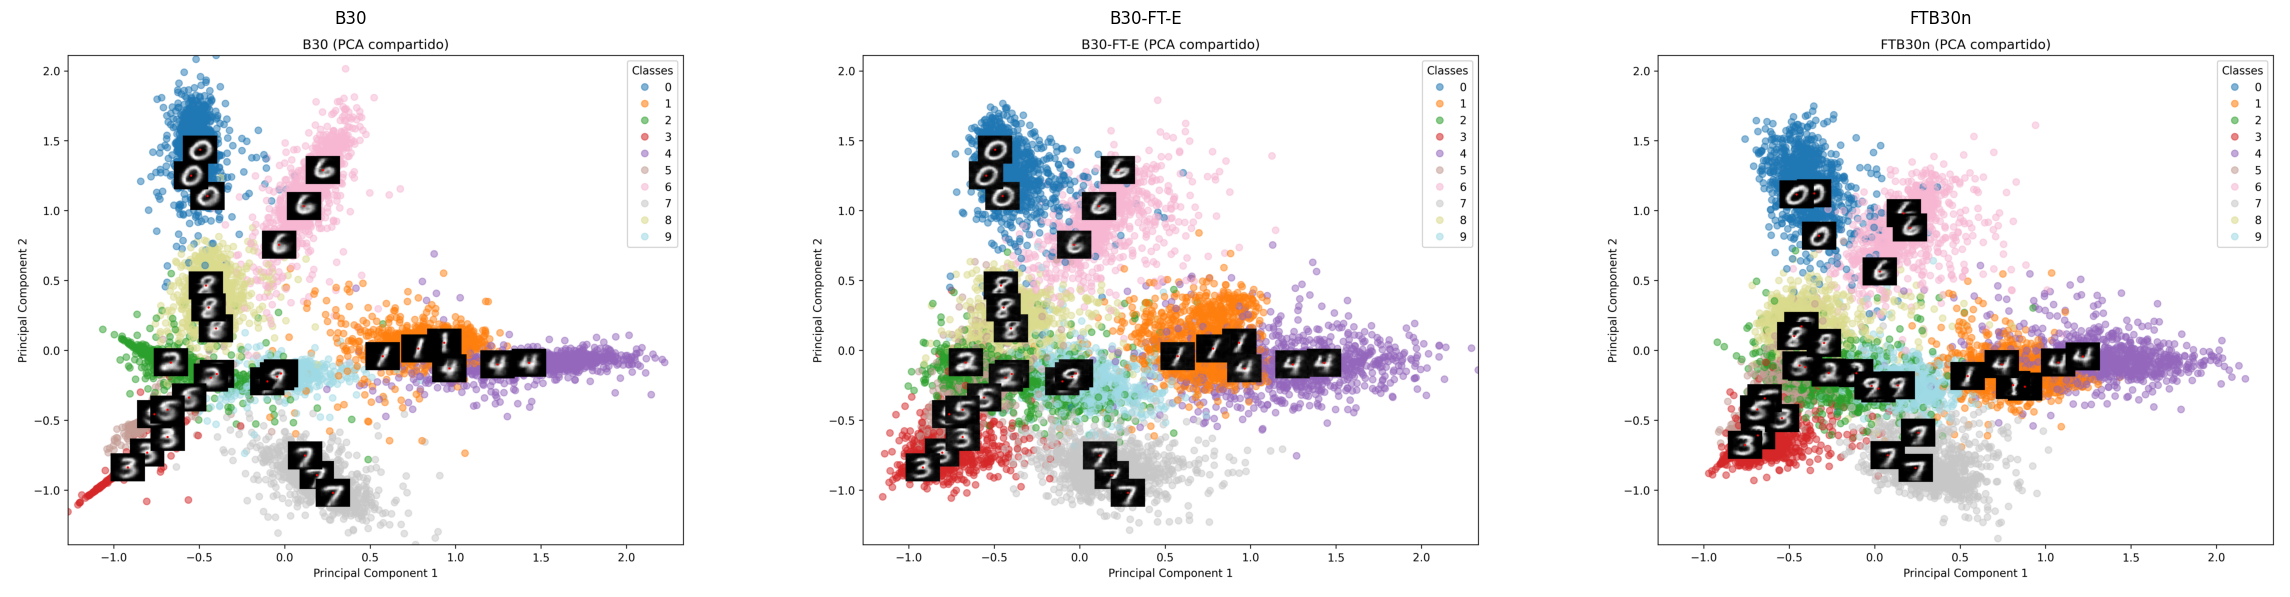

Usando checkpoint FTB30n: mnist_cae_adv00020.pth


In [18]:
# Comparacion justa de B30 vs FTB30n vs B30-FT-E con PCA compartido
import glob
import numpy as np

# 1) Usar test loader sin shuffle para que la comparacion sea totalmente reproducible
test_loader_eval = get_test_loader(
    data_folder,
    batch_size,
    shuffle=False,
    num_workers=n_workers,
    pin_memory=True,
)

# 2) Rutas de modelos
base_model_path = os.path.join(paths["B30"], "mnist_cae00750.pth")
b30_ft_e_checkpoint = os.path.join(
    "tfg_models", "B30", "B30-FT-E", "seed=1", "checkpoints",
    "B30_B30-FT-E_seed1_best_val_adv_acc.pth"
)

# Escoger automaticamente el ultimo checkpoint FTB30n disponible (advxxxxx.pth)
ftb30n_ckpts = sorted(glob.glob(os.path.join(paths["FTB30n"], "mnist_cae_adv*.pth")))
if not ftb30n_ckpts:
    raise FileNotFoundError(f"No se encontraron checkpoints FTB30n en: {paths['FTB30n']}")
ftb30n_model_path = ftb30n_ckpts[-1]

# 3) Cargar modelos
model_b30 = torch.load(base_model_path, map_location="cpu", weights_only=False)
model_b30.to(device)
model_b30.eval()

model_b30_ft_e = torch.load(base_model_path, map_location="cpu", weights_only=False)
state = torch.load(b30_ft_e_checkpoint, map_location="cpu")
model_b30_ft_e.load_state_dict(state["model_state"] if "model_state" in state else state)
model_b30_ft_e.to(device)
model_b30_ft_e.eval()

model_ftb30n = torch.load(ftb30n_model_path, map_location="cpu", weights_only=False)
model_ftb30n.to(device)
model_ftb30n.eval()

# 4) Codificar test para cada modelo
def encode_test_data(loader, model, device):
    encoded_data = []
    labels = []
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        encoded_batch = model.encoder(batch_x).detach().cpu().numpy().reshape(batch_x.size(0), -1)
        encoded_data.append(encoded_batch)
        labels.append(batch_y.numpy())
    return np.concatenate(encoded_data, axis=0), np.concatenate(labels, axis=0)

enc_b30, lbl_b30 = encode_test_data(test_loader_eval, model_b30, device)
enc_b30_ft_e, lbl_b30_ft_e = encode_test_data(test_loader_eval, model_b30_ft_e, device)
enc_ftb30n, lbl_ftb30n = encode_test_data(test_loader_eval, model_ftb30n, device)

# 5) Ajustar UNICO PCA compartido con las tres nubes latentes
shared_pca_new = PCA(n_components=2)
shared_pca_new.fit(np.concatenate([enc_b30, enc_b30_ft_e, enc_ftb30n], axis=0))

red_test_b30 = shared_pca_new.transform(enc_b30)
red_test_b30_ft_e = shared_pca_new.transform(enc_b30_ft_e)
red_test_ftb30n = shared_pca_new.transform(enc_ftb30n)

# 6) Proyectar prototipos en ese mismo PCA
proto_b30 = model_b30.prototype_layer.prototype_distances.to(device)
img_b30 = model_b30.decoder(proto_b30.reshape((-1, 10, 2, 2))).detach().cpu()
red_proto_b30 = shared_pca_new.transform(proto_b30.detach().cpu().numpy().reshape(proto_b30.size(0), -1))

proto_b30_ft_e = model_b30_ft_e.prototype_layer.prototype_distances.to(device)
img_b30_ft_e = model_b30_ft_e.decoder(proto_b30_ft_e.reshape((-1, 10, 2, 2))).detach().cpu()
red_proto_b30_ft_e = shared_pca_new.transform(proto_b30_ft_e.detach().cpu().numpy().reshape(proto_b30_ft_e.size(0), -1))

proto_ftb30n = model_ftb30n.prototype_layer.prototype_distances.to(device)
img_ftb30n_after = model_ftb30n.decoder(proto_ftb30n.reshape((-1, 10, 2, 2))).detach().cpu()
red_proto_ftb30n_after = shared_pca_new.transform(proto_ftb30n.detach().cpu().numpy().reshape(proto_ftb30n.size(0), -1))

# 7) Ejes compartidos entre los tres paneles
x_mins = [
    red_test_b30[:, 0].min(), red_test_b30_ft_e[:, 0].min(), red_test_ftb30n[:, 0].min(),
    red_proto_b30[:, 0].min(), red_proto_b30_ft_e[:, 0].min(), red_proto_ftb30n_after[:, 0].min()
]
x_maxs = [
    red_test_b30[:, 0].max(), red_test_b30_ft_e[:, 0].max(), red_test_ftb30n[:, 0].max(),
    red_proto_b30[:, 0].max(), red_proto_b30_ft_e[:, 0].max(), red_proto_ftb30n_after[:, 0].max()
]
y_mins = [
    red_test_b30[:, 1].min(), red_test_b30_ft_e[:, 1].min(), red_test_ftb30n[:, 1].min(),
    red_proto_b30[:, 1].min(), red_proto_b30_ft_e[:, 1].min(), red_proto_ftb30n_after[:, 1].min()
]
y_maxs = [
    red_test_b30[:, 1].max(), red_test_b30_ft_e[:, 1].max(), red_test_ftb30n[:, 1].max(),
    red_proto_b30[:, 1].max(), red_proto_b30_ft_e[:, 1].max(), red_proto_ftb30n_after[:, 1].max()
]
shared_xlim = (min(x_mins), max(x_maxs))
shared_ylim = (min(y_mins), max(y_maxs))

# 8) Guardar y mostrar comparacion lado a lado
save_dir_new = os.path.join("tfg_models", "B30", "B30-FT-E", "seed=1")
os.makedirs(save_dir_new, exist_ok=True)

save_b30 = os.path.join(save_dir_new, "B30_projection_shared_pca.png")
save_b30_ft_e = os.path.join(save_dir_new, "B30-FT-E_projection_shared_pca.png")
save_ftb30n_after = os.path.join(save_dir_new, "FTB30n_projection_shared_pca.png")

plot_prototype_projection_with_data(
    red_proto_b30, img_b30, red_test_b30, lbl_b30,
    "B30 (PCA compartido)", shared_xlim, shared_ylim, save_b30
)
plot_prototype_projection_with_data(
    red_proto_b30_ft_e, img_b30_ft_e, red_test_b30_ft_e, lbl_b30_ft_e,
    "B30-FT-E (PCA compartido)", shared_xlim, shared_ylim, save_b30_ft_e
)
plot_prototype_projection_with_data(
    red_proto_ftb30n_after, img_ftb30n_after, red_test_ftb30n, lbl_ftb30n,
    "FTB30n (PCA compartido)", shared_xlim, shared_ylim, save_ftb30n_after
)

im_b30 = plt.imread(save_b30)
im_b30_ft_e = plt.imread(save_b30_ft_e)
im_ftb30n_after = plt.imread(save_ftb30n_after)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].imshow(im_b30)
axes[0].set_title("B30")
axes[0].axis("off")

axes[1].imshow(im_b30_ft_e)
axes[1].set_title("B30-FT-E")
axes[1].axis("off")

axes[2].imshow(im_ftb30n_after)
axes[2].set_title("FTB30n")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Usando checkpoint FTB30n: {os.path.basename(ftb30n_model_path)}")